# Preámbulo Actividad 7 — Construcción del dataset socioeconómico RM

**INF-497 · Análisis de Datos Espaciales · 6 mayo**

Este notebook **no es la actividad** — genera el dataset que usarán en `07_actividad7_enunciado.ipynb`.

**Objetivo:** construir un perfil socioeconómico de las 52 comunas de la Región Metropolitana, combinando dos fuentes:

- **CASEN 2017** — ingreso autónomo y total per cápita (ya calculado en el preámbulo de la actividad 6, archivo `casen_rm_comunas.gpkg`).
- **Censo 2017 (personas)** — variables demográficas y educacionales agregadas a nivel comunal.

El resultado es un GeoPackage con **~8 variables socioeconómicas por comuna**, listo para clustering y regionalización.

**Ejecutar una sola vez.** En la actividad ustedes solo cargarán el archivo final.

> ⚠️ El microdato del Censo de Personas pesa ~2 GB. La lectura tarda 1–2 min y consume ~3 GB de RAM. Por eso solo cargamos las columnas necesarias y filtramos a la RM lo antes posible.

## 1. Setup

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd

warnings.filterwarnings("ignore")

ROOT = Path.cwd().resolve()
while not (ROOT / "pyproject.toml").exists():
    if ROOT.parent == ROOT:
        raise FileNotFoundError("No se encontró pyproject.toml — abre el notebook dentro del repo geodata")
    ROOT = ROOT.parent

# Microdatos Censo (fuera del repo)
CENSO_CSV = Path("/Users/calipsotornasol/Documents/data/external/censo2017/Microdato_Censo2017-Personas.csv")

# Dataset CASEN ya generado en la Actividad 6
CASEN_GPKG = ROOT / "datos/external/casen_rm/casen_rm_comunas.gpkg"

# Salida
SALIDA_DIR = ROOT / "datos/external/casen_rm"
SALIDA = SALIDA_DIR / "rm_socioeconomico.gpkg"

print("Project root:", ROOT)
print("Salida:", SALIDA)

Project root: /Users/calipsotornasol/Documents/geodata
Salida: /Users/calipsotornasol/Documents/geodata/datos/external/casen_rm/rm_socioeconomico.gpkg


## 2. Censo 2017 — variables relevantes

El microdato de personas tiene 17.5 millones de filas y 42 columnas. Solo necesitamos algunas:

| Columna | Significado |
|---|---|
| `REGION` | Código de región (13 = RM) |
| `COMUNA` | Código INE de comuna (5 dígitos) |
| `P09` | Edad (años) |
| `P11` | Lugar de nacimiento (2=esta comuna, 3=otra comuna, 4-9=extranjero) |
| `P15` | Tipo de enseñanza más alto cursado (1=jardín, …, 12=profesional, 13=magíster, 14=doctorado) |
| `P15A` | ¿Aprobó ese curso más alto? (1=sí) |
| `P16` | Se autoidentifica con pueblo originario (1=sí, 2=no) |
| `P17` | Situación laboral (1=trabajó por pago, 2=sin pago familiar, 3=con empleo pero ausente, …) |
| `ESCOLARIDAD` | Años de escolaridad |

Cargamos solo esas columnas, con `dtype` económico para ahorrar memoria:

In [2]:
cols = ["REGION", "COMUNA", "P09", "P11", "P15", "P15A", "P16", "P17", "ESCOLARIDAD"]
dtypes = {
    "REGION": "int16", "COMUNA": "int32",
    "P09": "int16", "P11": "int16", "P15": "int16",
    "P15A": "int16", "P16": "int16", "P17": "int16",
    "ESCOLARIDAD": "int16",
}

personas = pd.read_csv(CENSO_CSV, sep=";", usecols=cols, dtype=dtypes)
print(f"Total nacional: {len(personas):,} personas")

# Filtrar a la RM
rm = personas[personas["REGION"] == 13].copy()
del personas  # liberar memoria
print(f"RM: {len(rm):,} personas en {rm['COMUNA'].nunique()} comunas")
rm.head()

Total nacional: 17,574,003 personas
RM: 7,112,808 personas en 52 comunas


,REGION,COMUNA,P09,P11,P15,P15A,P16,P17,ESCOLARIDAD
610905,13,13605,38,2,11,1,2,1,15
610906,13,13605,40,2,12,1,2,1,17
610907,13,13605,9,2,5,2,2,98,3
610908,13,13605,0,1,98,98,2,98,0
610909,13,13605,87,2,6,2,2,7,99


## 3. Construcción de variables comunales

Definimos cada variable como una proporción o promedio sobre la población de la comuna. Algunas se calculan solo para subgrupos (ej. escolaridad para 25+, situación laboral para 15+).

**Códigos especiales del Censo:**
- `99` = Missing
- `98` = No aplica (la pregunta no correspondía al individuo)

Los excluimos antes de promediar.

In [3]:
# Limpieza de códigos no informativos
rm["ESCOLARIDAD"] = rm["ESCOLARIDAD"].where(rm["ESCOLARIDAD"] < 90)  # 98, 99 → NaN

# Indicadores binarios
rm["es_migrante"]      = (rm["P11"].between(4, 9)).astype(int)           # nació en el extranjero
rm["es_indigena"]      = (rm["P16"] == 1).astype(int)                    # se autoidentifica
rm["es_adulto_mayor"]  = (rm["P09"] >= 65).astype(int)                   # 65+
rm["es_menor"]         = (rm["P09"] < 15).astype(int)                    # <15
rm["educ_superior"]    = ((rm["P15"].between(11, 14)) & (rm["P15A"] == 1)).astype(int)  # técnico/profesional/postgrado completo
rm["trabaja"]          = (rm["P17"].isin([1, 3])).astype(int)            # trabajó por pago o tiene empleo

rm.head()

,REGION,COMUNA,P09,P11,P15,P15A,P16,P17,ESCOLARIDAD,es_migrante,es_indigena,es_adulto_mayor,es_menor,educ_superior,trabaja
610905,13,13605,38,2,11,1,2,1,15.0,0,0,0,0,1,1
610906,13,13605,40,2,12,1,2,1,17.0,0,0,0,0,1,1
610907,13,13605,9,2,5,2,2,98,3.0,0,0,0,1,0,0
610908,13,13605,0,1,98,98,2,98,0.0,0,0,0,1,0,0
610909,13,13605,87,2,6,2,2,7,NaN,0,0,1,0,0,0


In [4]:
# Población mayor de 25 (para escolaridad y educación superior)
adultos = rm[rm["P09"] >= 25]

# Población en edad de trabajar (15+)
edad_trabajar = rm[rm["P09"] >= 15]

# Agregaciones por comuna
by_comuna = rm.groupby("COMUNA").agg(
    poblacion_total = ("P09", "size"),
    edad_promedio   = ("P09", "mean"),
    pct_migrante    = ("es_migrante", "mean"),
    pct_indigena    = ("es_indigena", "mean"),
    pct_adulto_mayor= ("es_adulto_mayor", "mean"),
    pct_menor       = ("es_menor", "mean"),
)

by_comuna_adultos = adultos.groupby("COMUNA").agg(
    escolaridad_prom = ("ESCOLARIDAD", "mean"),
    pct_educ_superior= ("educ_superior", "mean"),
)

by_comuna_15 = edad_trabajar.groupby("COMUNA").agg(
    tasa_empleo = ("trabaja", "mean"),
)

# Razón de dependencia: (menores + adultos mayores) / población 15-64
by_comuna["razon_dependencia"] = (
    (by_comuna["pct_menor"] + by_comuna["pct_adulto_mayor"])
    / (1 - by_comuna["pct_menor"] - by_comuna["pct_adulto_mayor"])
)

# Unimos todo
censo_rm = (
    by_comuna
    .join(by_comuna_adultos)
    .join(by_comuna_15)
    .reset_index()
    .rename(columns={"COMUNA": "cod_comuna"})
)

# Pasamos las proporciones a porcentajes (más legibles)
for c in ["pct_migrante", "pct_indigena", "pct_adulto_mayor", "pct_menor", "pct_educ_superior", "tasa_empleo"]:
    censo_rm[c] *= 100

print(censo_rm.shape)
censo_rm.head()

(52, 11)


,cod_comuna,poblacion_total,edad_promedio,pct_migrante,pct_indigena,pct_adulto_mayor,pct_menor,razon_dependencia,escolaridad_prom,pct_educ_superior,tasa_empleo
0,13101,404495,34.463111,20.789874,8.113079,7.421353,12.188037,0.243926,13.760598,47.798183,70.338828
1,13102,80832,35.692585,3.094072,11.082245,11.887619,20.082393,0.469940,10.811998,18.913258,58.112355
2,13103,132622,35.964320,3.271705,15.694229,12.363710,19.787818,0.473873,9.561461,8.396184,56.611737
3,13104,126955,37.325312,4.529164,10.105943,13.746603,18.596353,0.478043,10.588156,15.954014,56.928183
4,13105,162505,35.993957,1.831328,11.899326,12.227316,20.317529,0.482466,10.252523,13.754693,55.768102


## 4. Cargar dataset CASEN-RM (generado en Actividad 6)

Tomamos solo las columnas relevantes para la actividad: ingreso autónomo per cápita 2017 y la geometría comunal. También calculamos cuánto eleva las transferencias estatales el ingreso (`pct_ganancia_transf`).

In [5]:
casen = gpd.read_file(CASEN_GPKG)
casen = casen[[
    "cod_comuna", "nom_comuna", "nom_prov",
    "ypc_aut_2017", "ypc_tot_2017",
    "geometry",
]].copy()

casen["pct_ganancia_transf"] = (
    100 * (casen["ypc_tot_2017"] - casen["ypc_aut_2017"]) / casen["ypc_aut_2017"]
)

casen.head()

,cod_comuna,nom_comuna,nom_prov,ypc_aut_2017,ypc_tot_2017,geometry,pct_ganancia_transf
0,13404,PAINE,MAIPO,285365.876995,353275.520186,"POLYGON ((350033.920 6265707.472, 350106.705 6...",23.797394
1,13402,BUIN,MAIPO,215822.686195,272555.328224,"POLYGON ((348666.339 6275861.274, 348652.409 6...",26.286691
2,13124,PUDAHUEL,SANTIAGO,235630.811008,297166.493830,"POLYGON ((333540.425 6307203.281, 333624.972 6...",26.115296
3,13103,CERRO NAVIA,SANTIAGO,196263.371949,262109.907533,"POLYGON ((340136.215 6301567.277, 340172.841 6...",33.550089
4,13301,COLINA,CHACABUCO,392879.514299,477950.576987,"POLYGON ((350790.367 6352972.781, 350751.311 6...",21.653219


## 5. Unión final

In [6]:
gdf = casen.merge(censo_rm, on="cod_comuna", how="left")

# Reordenamos columnas
cols_orden = [
    "cod_comuna", "nom_comuna", "nom_prov",
    # Ingreso (CASEN)
    "ypc_aut_2017", "ypc_tot_2017", "pct_ganancia_transf",
    # Educación (Censo)
    "escolaridad_prom", "pct_educ_superior",
    # Empleo (Censo)
    "tasa_empleo",
    # Demografía (Censo)
    "edad_promedio", "pct_adulto_mayor", "pct_menor", "razon_dependencia",
    "pct_migrante", "pct_indigena",
    "poblacion_total",
    "geometry",
]
gdf = gdf[cols_orden]

print(f"Filas: {len(gdf)} (esperado: 52)")
print(f"NaN totales: {gdf.drop(columns='geometry').isna().sum().sum()}")
gdf.head()

Filas: 52 (esperado: 52)
NaN totales: 0


,cod_comuna,nom_comuna,nom_prov,ypc_aut_2017,ypc_tot_2017,pct_ganancia_transf,escolaridad_prom,pct_educ_superior,tasa_empleo,edad_promedio,pct_adulto_mayor,pct_menor,razon_dependencia,pct_migrante,pct_indigena,poblacion_total,geometry
0,13404,PAINE,MAIPO,285365.876995,353275.520186,23.797394,10.139286,16.309352,56.632357,34.498619,9.736253,21.885952,0.462463,2.318614,8.547396,72759,"POLYGON ((350033.920 6265707.472, 350106.705 6..."
1,13402,BUIN,MAIPO,215822.686195,272555.328224,26.286691,10.888701,22.457746,58.878866,33.673950,8.749250,22.431532,0.453082,1.439750,8.144782,96614,"POLYGON ((348666.339 6275861.274, 348652.409 6..."
2,13124,PUDAHUEL,SANTIAGO,235630.811008,297166.493830,26.115296,11.034397,19.780937,60.356140,34.360958,8.483975,20.845184,0.415011,2.185911,12.287825,230293,"POLYGON ((333540.425 6307203.281, 333624.972 6..."
3,13103,CERRO NAVIA,SANTIAGO,196263.371949,262109.907533,33.550089,9.561461,8.396184,56.611737,35.964320,12.363710,19.787818,0.473873,3.271705,15.694229,132622,"POLYGON ((340136.215 6301567.277, 340172.841 6..."
4,13301,COLINA,CHACABUCO,392879.514299,477950.576987,21.653219,11.450715,28.829218,60.498396,31.114057,5.964831,26.251137,0.475274,4.096247,8.808060,146207,"POLYGON ((350790.367 6352972.781, 350751.311 6..."


## 6. Sanity check visual

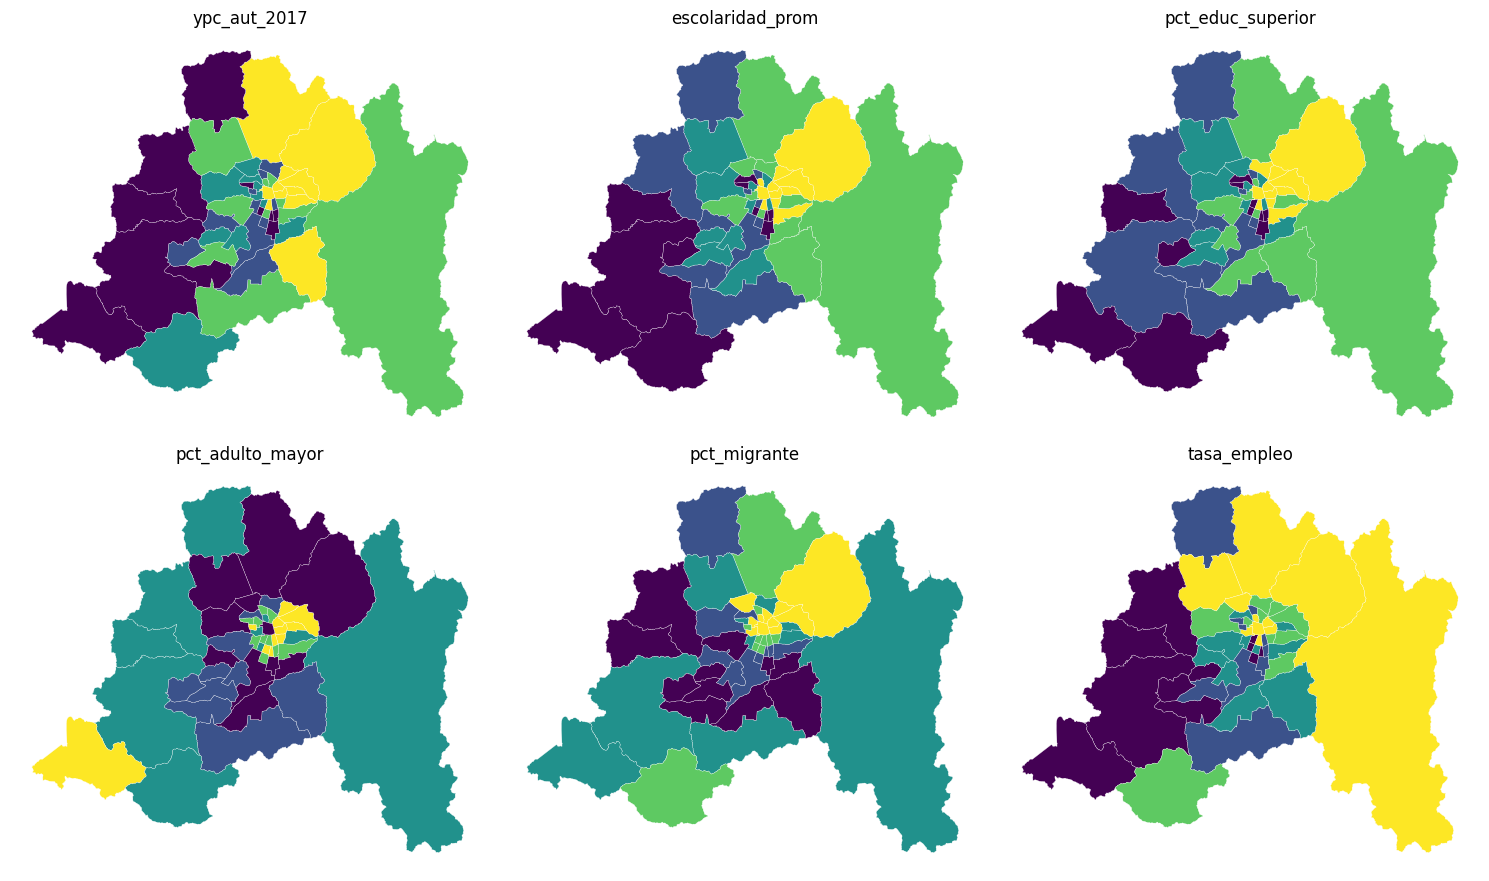

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
variables_check = [
    "ypc_aut_2017", "escolaridad_prom", "pct_educ_superior",
    "pct_adulto_mayor", "pct_migrante", "tasa_empleo",
]
for ax, var in zip(axes.flatten(), variables_check):
    gdf.plot(column=var, scheme="Quantiles", k=5, cmap="viridis",
             linewidth=0.2, edgecolor="white", ax=ax)
    ax.set_title(var)
    ax.set_axis_off()
plt.tight_layout()
plt.show()

## 7. Exportar GeoPackage

In [8]:
gdf.to_file(SALIDA, driver="GPKG")
print(f"Guardado: {SALIDA}")
print(f"Tamaño: {SALIDA.stat().st_size / 1024:.1f} KB")

Guardado: /Users/calipsotornasol/Documents/geodata/datos/external/casen_rm/rm_socioeconomico.gpkg
Tamaño: 2368.0 KB


## Listo

En la actividad cargan el dataset así:

```python
import geopandas as gpd
gdf = gpd.read_file("../datos/external/casen_rm/rm_socioeconomico.gpkg")
```

**Variables disponibles** (todas a nivel comuna RM):

| Variable | Fuente | Significado |
|---|---|---|
| `ypc_aut_2017` | CASEN | Ingreso autónomo per cápita |
| `ypc_tot_2017` | CASEN | Ingreso total per cápita (post-transferencias) |
| `pct_ganancia_transf` | CASEN | % en que las transferencias del Estado elevan el ingreso |
| `escolaridad_prom` | Censo | Años promedio de escolaridad (25+) |
| `pct_educ_superior` | Censo | % adultos 25+ con educación superior completa |
| `tasa_empleo` | Censo | % de población 15+ que trabajaba |
| `edad_promedio` | Censo | Edad promedio |
| `pct_adulto_mayor` | Censo | % de población 65+ |
| `pct_menor` | Censo | % de población <15 |
| `razon_dependencia` | Censo | (menores + mayores) / (15-64) |
| `pct_migrante` | Censo | % nacidos fuera de Chile |
| `pct_indigena` | Censo | % autoidentificación pueblos originarios |
| `poblacion_total` | Censo | Población total comunal |
